In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

from pathlib import Path

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

data_dir = Path('/gpfs/data/fs71925/shepp123/frgs_6d/')
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Sebastian\AppData\Local\Programs\Python\Python312\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Sebastian\AppData\Local\Programs\Python\Python312\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\traitlets\config\application.py", line 1075, 

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## visualize vertex

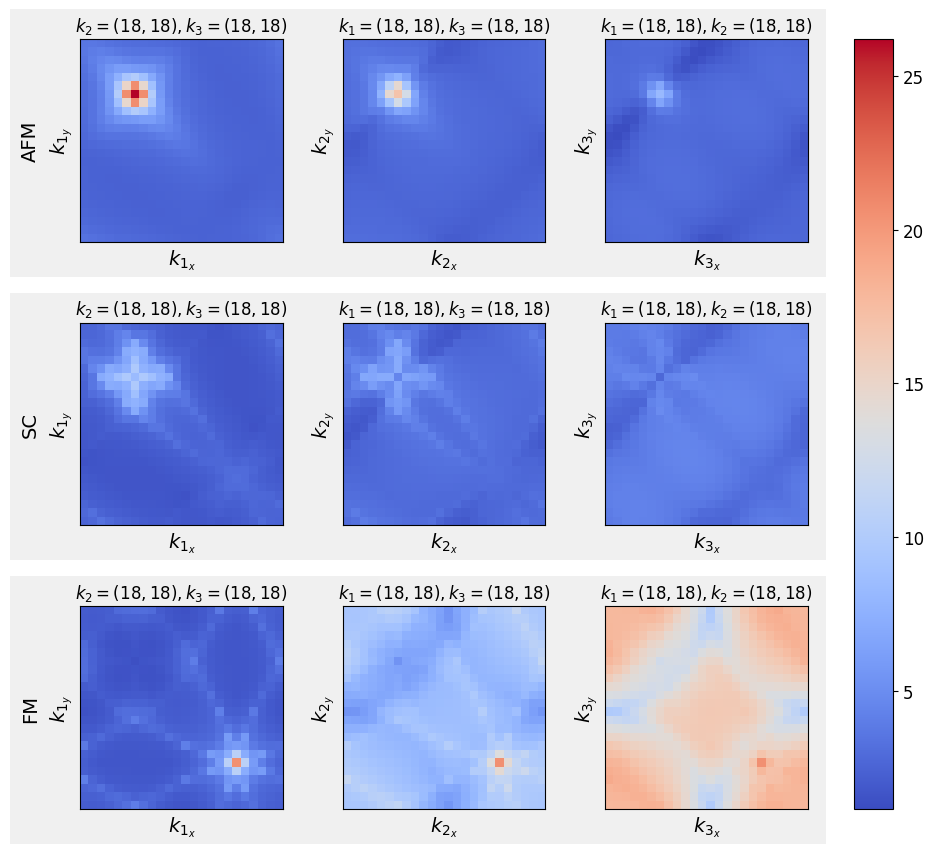

In [116]:
files_names = ['tp0.090000_mu0.360000', 'tp0.270000_mu1.080000', 'tp0.410000_mu1.640000']
vertices = [AutoEncoderVertex24x6Dataset.load_from_file(data_dir / f'{fn}.h5') for fn in files_names]
vertvis.plot_compare_slices(vertices, i=18, axis=3, vmin=None, vmax=None)

## vertex statistics

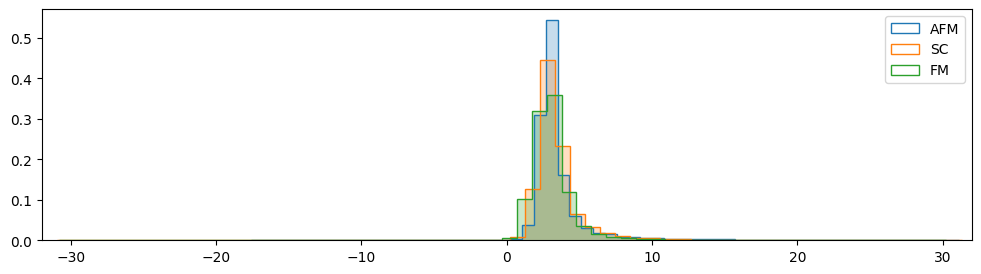

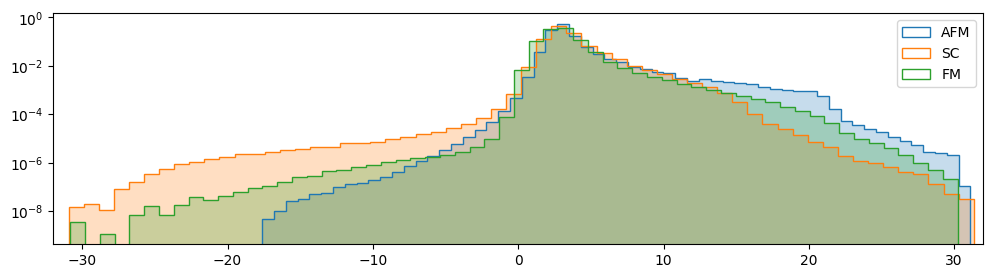

,min,max,mean,sum
AFM,-17.621026,31.116854,3.516467,13440147922.163141
SC,-30.943928,31.344199,3.435302,13129930305.072977
FM,-30.830774,30.236403,3.128338,11956693254.854389


In [3]:
df, data = verteval.vertex_statistics(data_dir)
verteval.plot_statistics(data)
verteval.plot_statistics(data, log=True)
df

## correlation

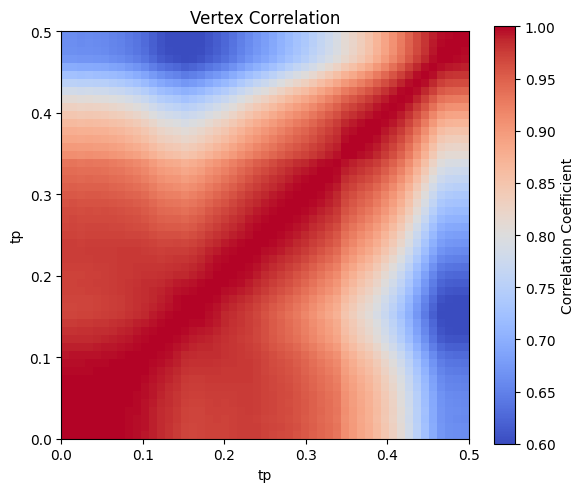

In [9]:
cor_mat = np.load(f'cor_mat_real.npy')
vertvis.plot_correlation(cor_mat, "Vertex Correlation", vmin=0.6)

In [10]:
cor_mat.min()

np.float64(0.5897979984026432)

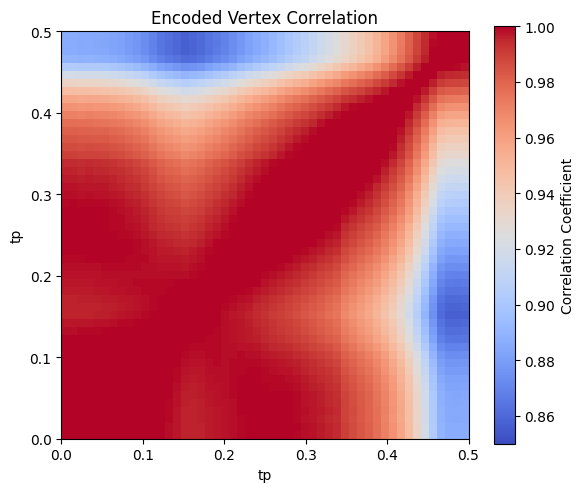

In [6]:
cor_mat = np.load(f'cor_mat_latent_1-1-ld32.npy')
vertvis.plot_correlation(cor_mat, "Encoded Vertex Correlation", vmin=0.85)

In [4]:
cor_mat.min()

np.float64(0.8568989038467407)

## compare autoencoder models

In [14]:
rmse_summary = rmse_df.drop(columns=['tp', 'train_data', 'contrastive']).groupby(['run_id', 'ld', 's']).mean()
rmse_summary['train_rmse'] = rmse_df[rmse_df['train_data']].drop(columns=['tp', 'train_data', 'contrastive']).groupby(['run_id', 'ld', 's']).mean()
rmse_summary['test_rmse'] = rmse_df[~rmse_df['train_data']].drop(columns=['tp', 'train_data', 'contrastive']).groupby(['run_id', 'ld', 's']).mean()
rmse_summary

rmse  train_rmse  test_rmse
run_id ld s                                     
1_1    32 24000  0.007771    0.007771        NaN
1_2    32 24000  0.066215    0.066215        NaN
2_1_1  8  24000  0.169867    0.140872   0.211288
       16 24000  0.097626    0.077321   0.126634
       20 24000  0.074753    0.055514   0.102237
       24 24000  0.046875    0.032327   0.067657
       32 2000   0.068156    0.055987   0.085542
          8000   0.040277    0.028698   0.056819
          12000  0.047274    0.033985   0.066258
          16000  0.018830    0.009967   0.031492
          24000  0.023504    0.015824   0.034476
2_1_2  32 24000  0.043141    0.030556   0.061120
2_2_1  32 24000  0.011346    0.007874   0.014685
2_2_2  32 24000  0.050307    0.051612   0.049053
2_3_1  32 24000  0.024447    0.019538   0.029552
2_3_2  32 24000  0.067075    0.064569   0.069681
3_1    32 24000  0.016433    0.010156   0.017963
3_2    32 24000  0.054052    0.014287   0.072230
3_3    32 24000  0.019987    0.008324   0.024400

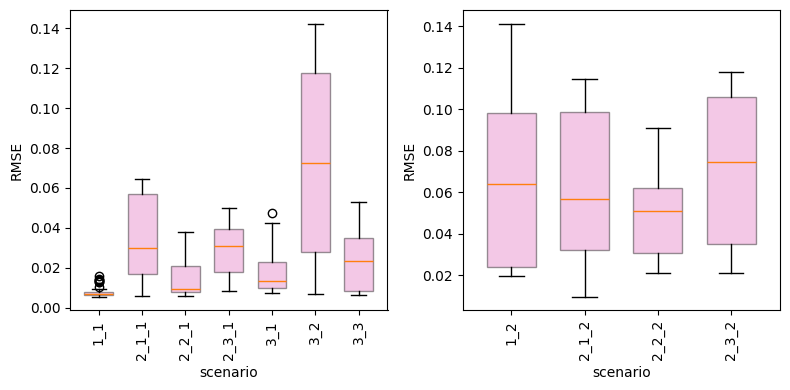

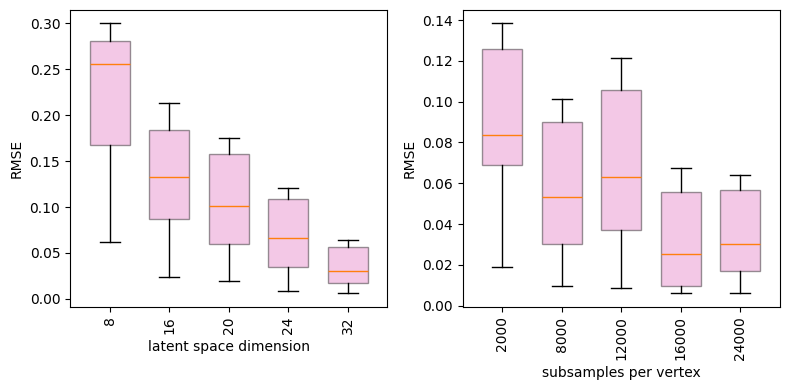

In [25]:
verteval.plot_rmse_boxplots(rmse_df, figsize=(8, 4), train_data=False)

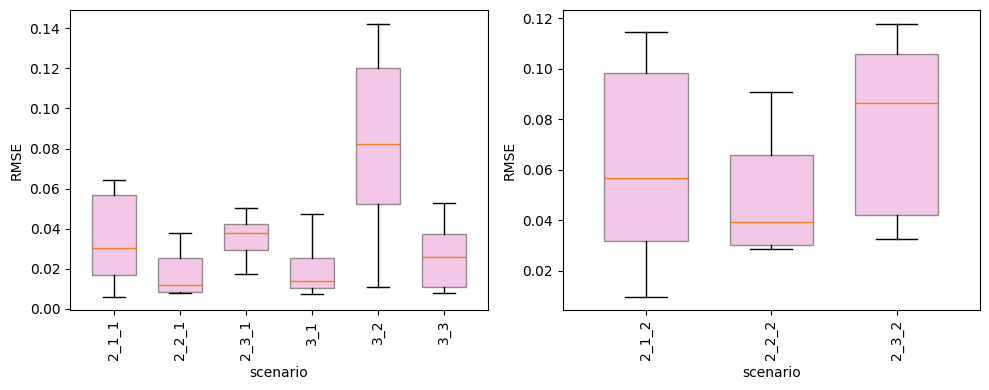

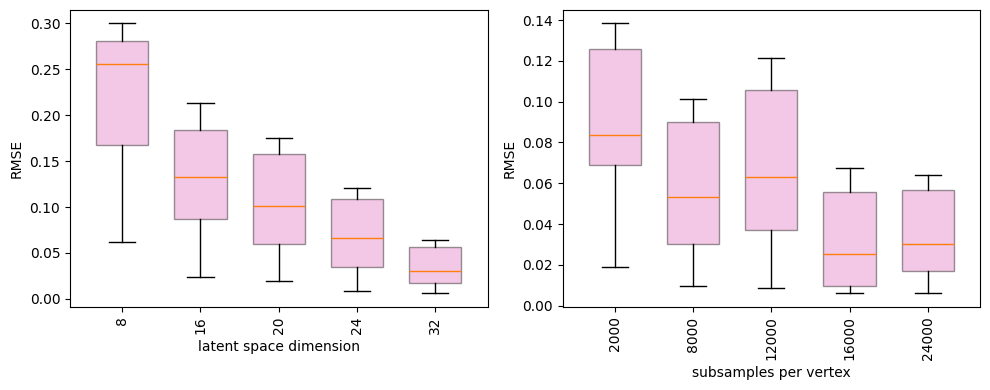

In [3]:
# test vertices only
df = rmse_df.copy()
df = df[df['train_data'] == False]
df = df[(df['run_id'].str.startswith('2_1_') & ((df['tp'] >= 0.2) | (df['tp'] < 0.33)))
        | (df['run_id'].str.startswith('2_2_') & ((df['tp'] < 0.2)))
        | (df['run_id'].str.startswith('2_3_') & ((df['tp'] >= 0.33)))
        | ((df['run_id'] == '3_1') & ((df['tp'] < 0.2) | (df['tp'] >= 0.33)))
        | ((df['run_id'] == '3_2') & ((df['tp'] >= 0.2)))
        | ((df['run_id'] == '3_3') & ((df['tp'] < 0.33)))]
verteval.plot_rmse_boxplots(df, figsize=(10, 4), train_data=False)

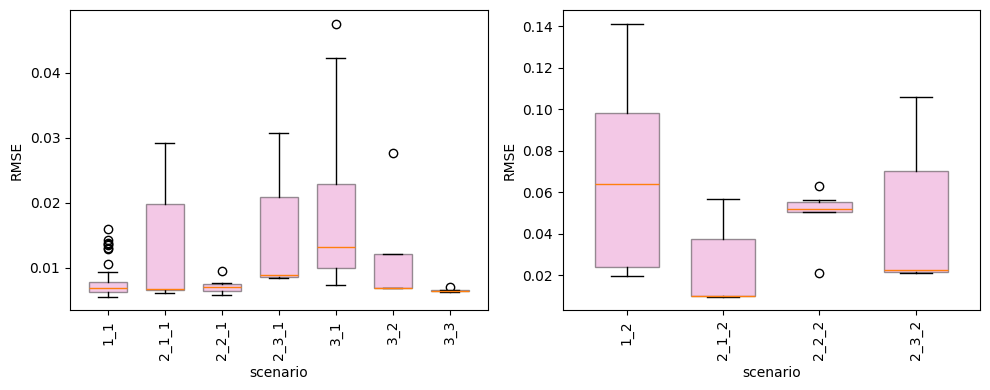

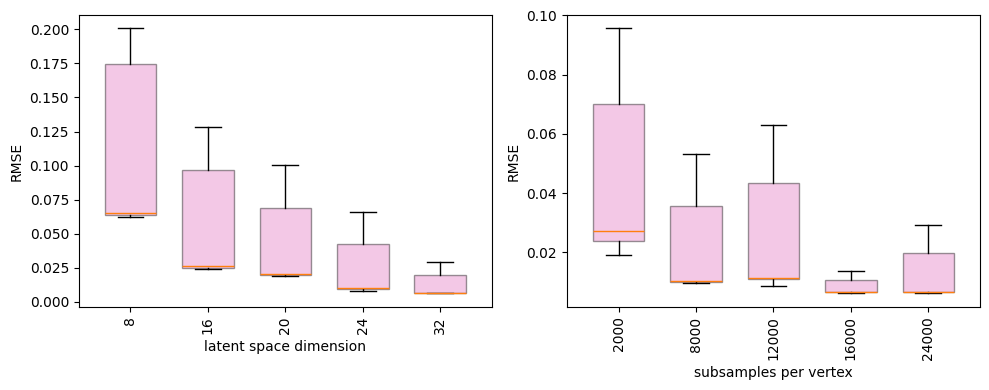

In [10]:
# train vertices only
df = rmse_df.copy()
df = df[df['run_id'].str.startswith('1_') | (df['train_data'] == False)]
df = df[df['run_id'].str.startswith('1_')
        | (df['run_id'].str.startswith('2_1_') & ((df['tp'] < 0.2) | (df['tp'] >= 0.33)))
        | (df['run_id'].str.startswith('2_2_') & ((df['tp'] >= 0.2)))
        | (df['run_id'].str.startswith('2_3_') & ((df['tp'] < 0.33)))
        | ((df['run_id'] == '3_1') & ((df['tp'] >= 0.2) | (df['tp'] < 0.33)))
        | ((df['run_id'] == '3_2') & ((df['tp'] < 0.2)))
        | ((df['run_id'] == '3_3') & ((df['tp'] >= 0.33)))]
verteval.plot_rmse_boxplots(df, figsize=(10, 4), train_data=False)

In [65]:
df = df.reset_index()
df['run_id'] = df['run_id'].str.replace('_', '-')
df

,run_id,ld,s,rmse
0,3-1,32,24000,0.022396
1,3-2,32,24000,0.047253
2,3-3,32,24000,0.056652


In [66]:
print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & ld & s & rmse \\
\midrule
3-1 & 32 & 24000 & 0.022 \\
3-2 & 32 & 24000 & 0.047 \\
3-3 & 32 & 24000 & 0.057 \\
\bottomrule
\end{tabular}



mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519
training data only - mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519


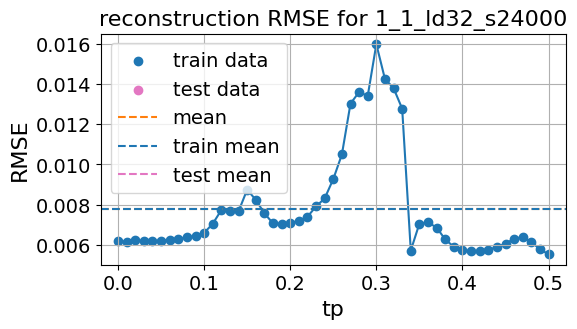

mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296


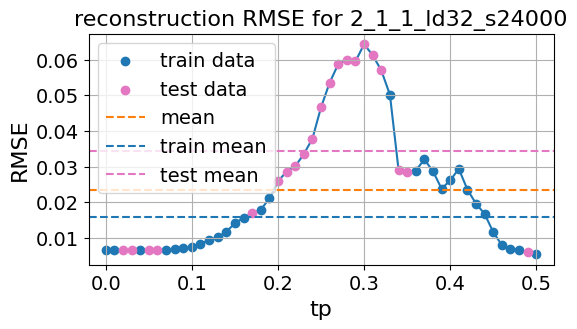

mean: 0.011346324672715713, min: 0.0058296047811714, max: 0.0376805900382426
training data only - mean: 0.007874428499352064, min: 0.0058585200357042, max: 0.0126556805233798
test data only - mean: 0.014684686377873067, min: 0.0058296047811714, max: 0.0376805900382426


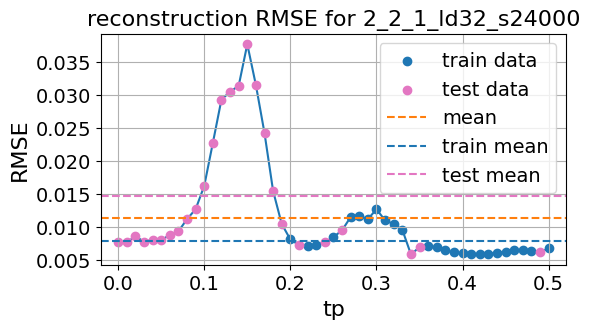

mean: 0.024446766145674214, min: 0.008417594942537, max: 0.0501274356605866
training data only - mean: 0.019537599560778503, min: 0.0084585091309584, max: 0.0412011397862826
test data only - mean: 0.029552299393965753, min: 0.008417594942537, max: 0.0501274356605866


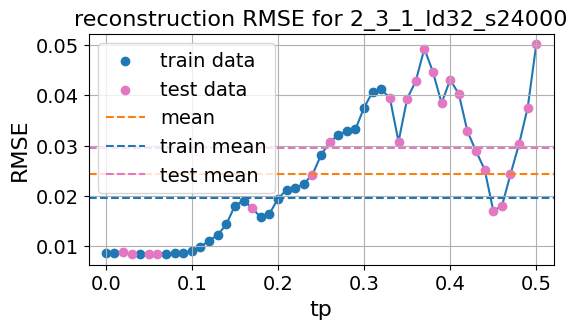

mean: 0.016432640288140465, min: 0.0073222943543964, max: 0.0475276224161039
training data only - mean: 0.01015621203985333, min: 0.0085851273079696, max: 0.0117938620285331
test data only - mean: 0.01796347644625928, min: 0.0073222943543964, max: 0.0475276224161039


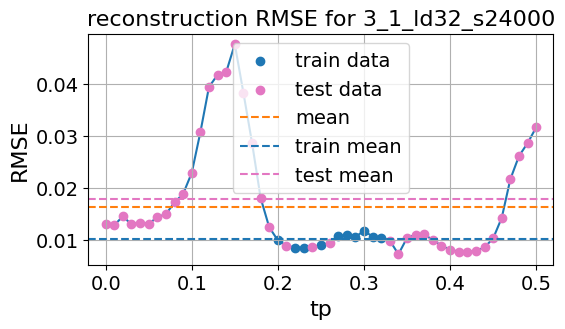

mean: 0.05405205146477475, min: 0.0068304631837742, max: 0.1423498029275165
training data only - mean: 0.01428682297744393, min: 0.0069133213537977, max: 0.035640568504099
test data only - mean: 0.07223044163041169, min: 0.0068304631837742, max: 0.1423498029275165


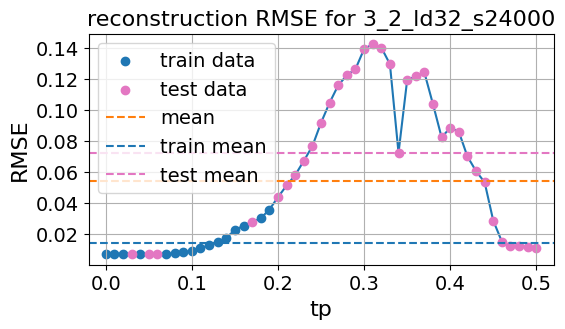

mean: 0.01998738447340126, min: 0.0061421676426792, max: 0.0528070905557745
training data only - mean: 0.008324228514100543, min: 0.0061421676426792, max: 0.0299489592649665
test data only - mean: 0.024400470512055586, min: 0.0063116254150922, max: 0.0528070905557745


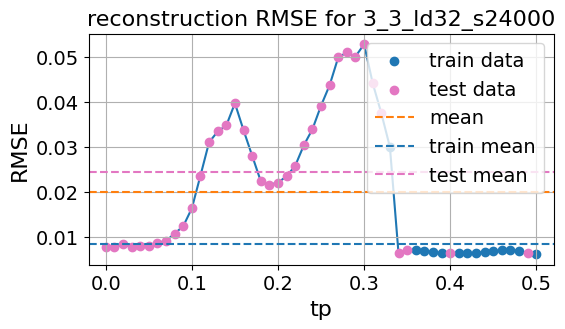

In [4]:
for (run_id, ld, s), group in rmse_df[~rmse_df['contrastive'] & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000)].groupby(['run_id', 'ld', 's']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}', figsize=(6,3), font_size=16)

## convergence

In [ ]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir()])
run_ids = ['1_1', '1_2', '2_1_1', '2_1_2', '2_2_1', '2_2_2', '2_3_1', '2_3_2', '3_1', '3_2', '3_3']  # '2_1_1_nextTp'
labels = []
for f in folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    labels.append(f"{pref}, {suff}")
tensorboard_data = vis.get_tensorboard_data(base_path, folders, labels)
tensorboard_data.to_csv('tensorboard_data.csv', index=False)

In [34]:
tensorboard_data = pd.read_csv('tensorboard_data.csv')
tensorboard_data['ld'] = tensorboard_data['run'].str.extract(r'.*ld(\d+)').astype(pd.Int16Dtype()).fillna(32)
tensorboard_data['s'] = tensorboard_data['run'].str.extract(r'.*s(\d+)').astype(pd.Int16Dtype()).fillna(24000)
tensorboard_data['run'] = tensorboard_data['run'].str.split(',').str[0]

tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)
tensorboard_stats

wall time [hours]  epochs  min. loss  epoch of min. loss  \
run   ld s                                                                 
1_1   32 24000              40.99   24999   0.000061               22990   
1_2   32 24000              29.99   49999   0.017237               49507   
2_1_1 8  24000              24.41   24999   0.023746               24952   
      16 24000              24.17   24999   0.008373               24995   
      20 24000              24.29   24999   0.004415               24922   
      24 24000              24.36   24999   0.001679               24652   
      32 2000                2.38   24999   0.003523               24904   
         8000                8.31   24999   0.001009               24984   
         12000              12.06   24999   0.001851               24835   
         16000              15.93   24999   0.000074               20349   
         24000              24.40   24999   0.000371               24822   
2_1_2 32 24000              15.42   49999   0.002880               19245   
2_2_1 32 24000              20.24   24999   0.000062               23291   
2_2_2 32 24000              13.57   49999   0.009826               48288   
2_3_1 32 24000              21.33   24999   0.000548               24024   
2_3_2 32 24000              15.52   49999   0.014065               49884   
3_1   32 24000               8.26   24999   0.000077               24280   
3_2   32 24000              12.81   24999   0.000324               24881   
3_3   32 24000              11.27   24999   0.000090               13796   

                max. epochs w/o decrease  epoch of min. loss (10% threshold)  
run   ld s                                                                    
1_1   32 24000                      6539                               16451  
1_2   32 24000                      1136                               40063  
2_1_1 8  24000                       283                               12936  
      16 24000                       364                               16091  
      20 24000                       449                               23341  
      24 24000                      2505                               16547  
      32 2000                        170                               24028  
         8000                        881                               19710  
         12000                       758                               18261  
         16000                      2238                               20168  
         24000                      1834                               18912  
2_1_2 32 24000                      1106                               12852  
2_2_1 32 24000                      7190                               15506  
2_2_2 32 24000                      2211                               36979  
2_3_1 32 24000                      1940                               20555  
2_3_2 32 24000                       652                               41767  
3_1   32 24000                      1685                               23381  
3_2   32 24000                       743                               22936  
3_3   32 24000                      4530                                5430

In [ ]:
# plot run-times
# plot min loss epochs

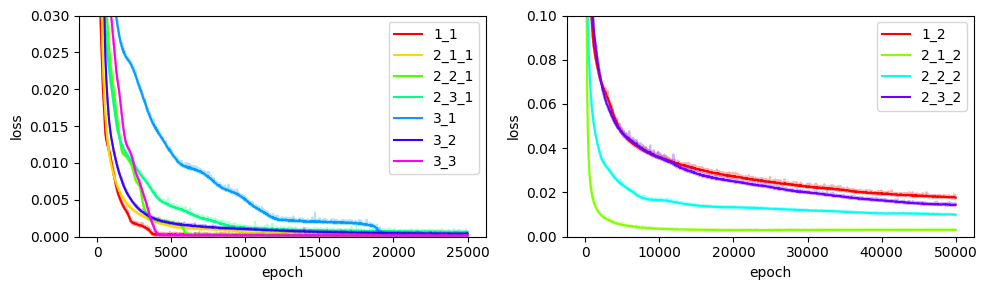

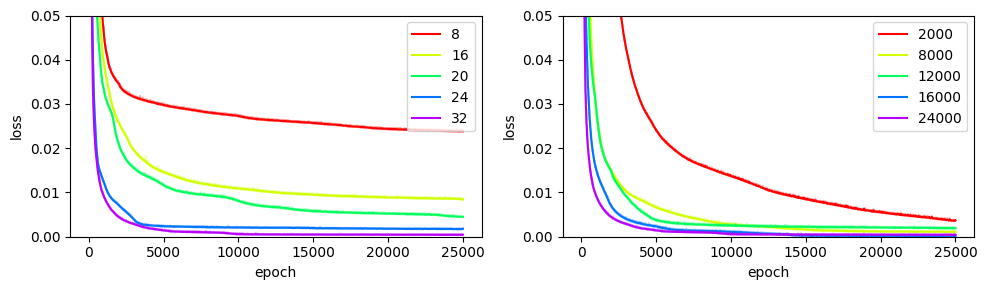

In [45]:
verteval.plot_loss_progress(tensorboard_data.dropna(), y_maxs=(0.03, 0.1, 0.05, 0.05), figsize=(10, 3), log=False)

## compare phase classifier models

In [31]:
classification_df.set_index(['run_id', 'ld', 's'])

,,,f1,conf_mat
run_id,ld,s,,
2_1_1,32,8000,0.958721,"[[1.0, 0.0, 0.0], [0.03445, 0.8989625, 0.06658..."
2_1_2,32,24000,0.969004,"[[1.0, 0.0, 0.0], [0.0272375, 0.92625, 0.04651..."
3_2,32,24000,0.961452,"[[1.0, 0.0, 0.0], [0.032825, 0.9044375, 0.0627..."
2_2_2,32,24000,0.967883,"[[1.0, 0.0, 0.0], [0.0252875, 0.92423125, 0.05..."
2_1_1,8,24000,0.952377,"[[1.0, 0.0, 0.0], [0.0422375, 0.8940875, 0.063..."
2_3_2,32,24000,0.970094,"[[1.0, 0.0, 0.0], [0.01784375, 0.93701875, 0.0..."
3_1,32,24000,0.956281,"[[1.0, 0.0, 0.0], [0.0387, 0.89531875, 0.06598..."
1_1,32,24000,0.956973,"[[1.0, 0.0, 0.0], [0.04370625, 0.8924, 0.06389..."
2_1_1,20,24000,0.963304,"[[1.0, 0.0, 0.0], [0.0316125, 0.91429375, 0.05..."


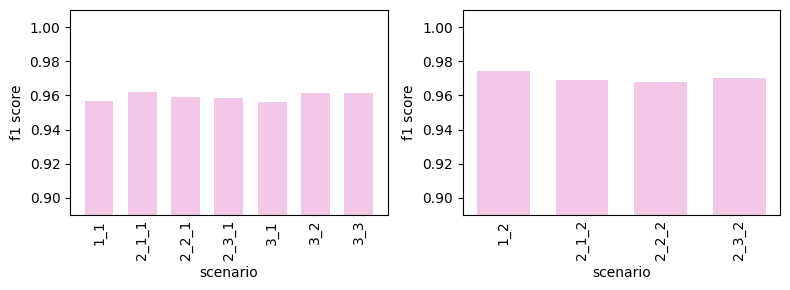

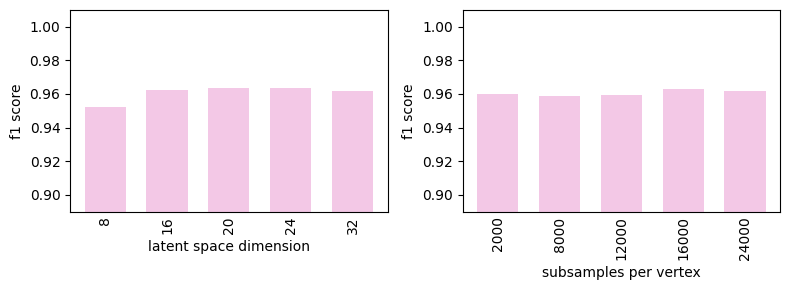

In [34]:
verteval.plot_classification_results(classification_df, figsize=(8, 3))

In [95]:
df = df.reset_index()
df['run_id'] = df['run_id'].str.replace('_', '-')
df

,run_id,ld,s,f1
0,2-1-2,8,24000,0.951040
1,2-1-2,16,24000,0.959179
2,2-1-2,20,24000,0.966148
3,2-1-2,24,24000,0.965585
4,2-1-2,32,24000,0.966148


In [96]:
print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & ld & s & f1 \\
\midrule
2-1-2 & 8 & 24000 & 0.951 \\
2-1-2 & 16 & 24000 & 0.959 \\
2-1-2 & 20 & 24000 & 0.966 \\
2-1-2 & 24 & 24000 & 0.966 \\
2-1-2 & 32 & 24000 & 0.966 \\
\bottomrule
\end{tabular}



2_1_1_ld32_s8000


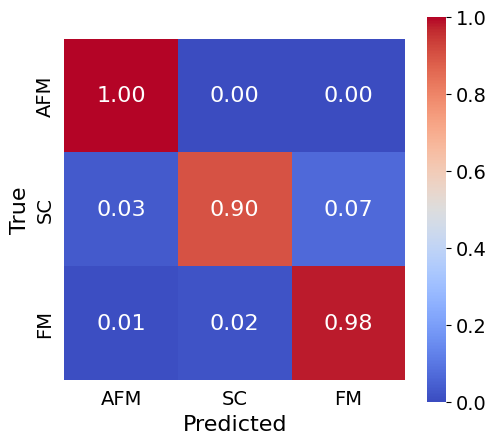

2_1_2_ld32_s24000


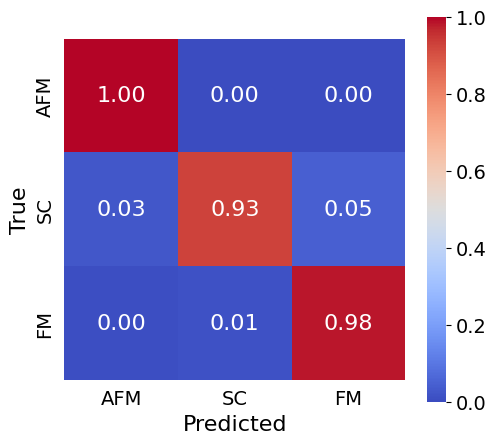

3_2_ld32_s24000


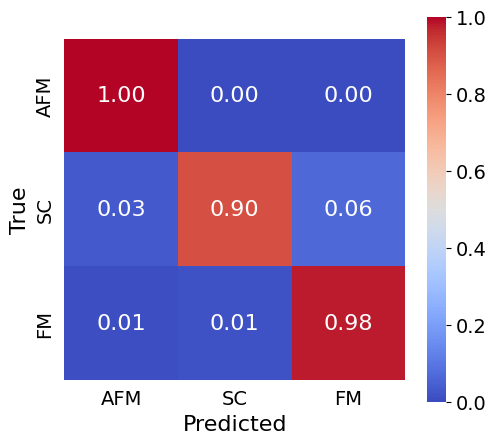

2_2_2_ld32_s24000


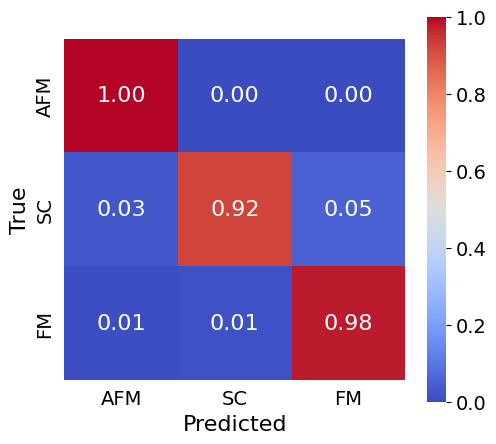

2_1_1_ld8_s24000


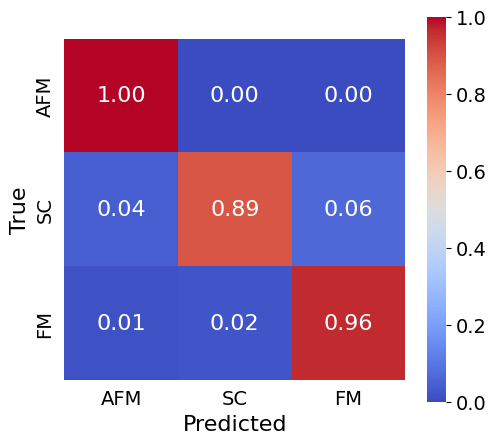

2_3_2_ld32_s24000


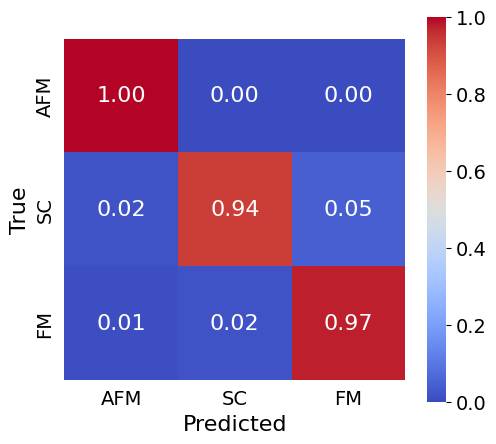

3_1_ld32_s24000


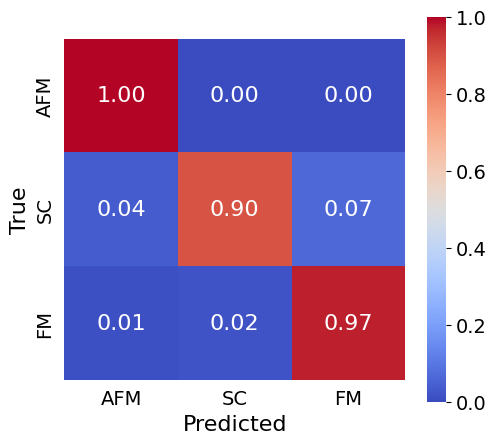

1_1_ld32_s24000


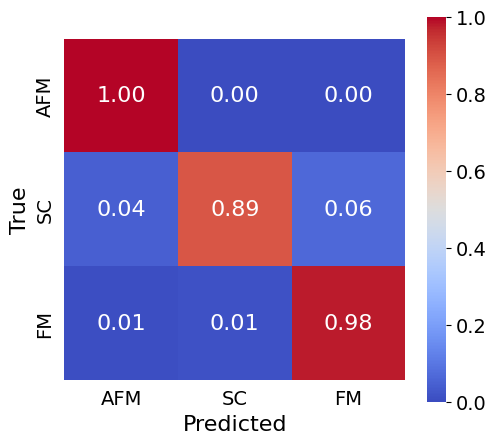

2_1_1_ld20_s24000


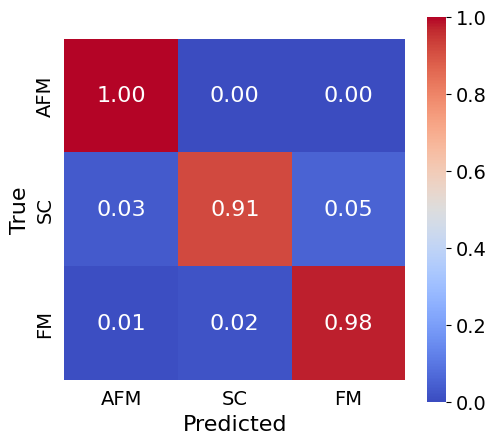

2_2_1_ld32_s24000


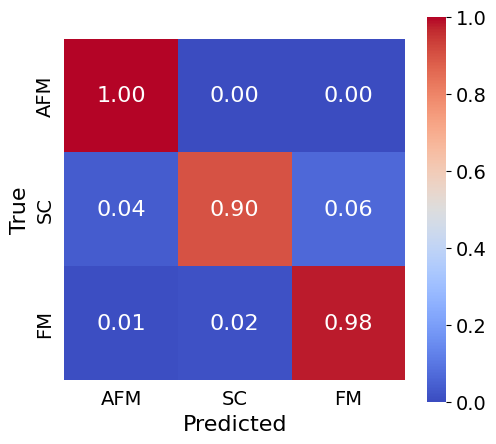

3_3_ld32_s24000


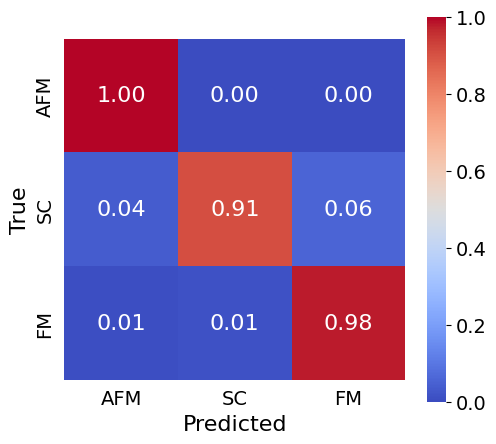

2_1_1_ld32_s24000


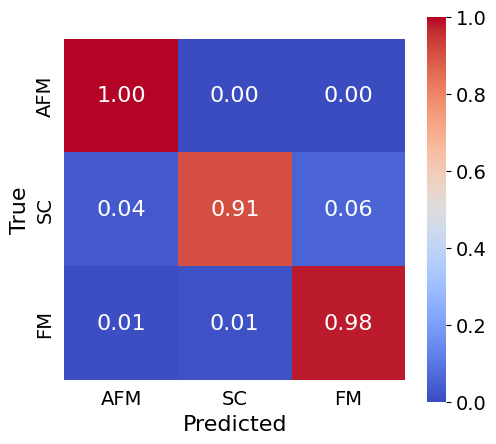

2_1_1_ld32_s12000


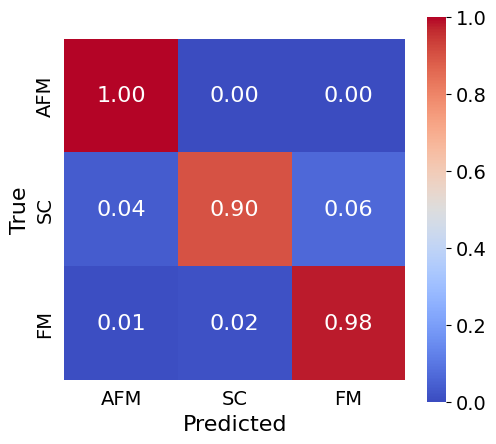

2_1_1_ld32_s16000


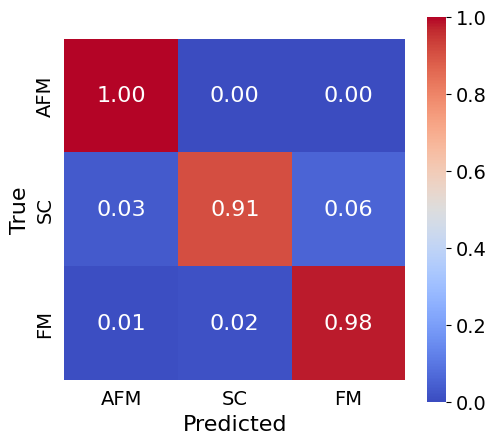

2_1_1_ld24_s24000


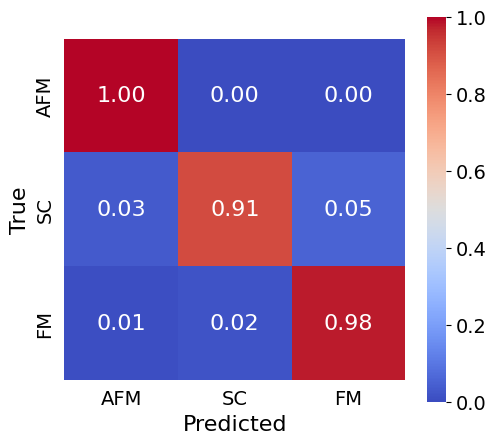

1_2_ld32_s24000


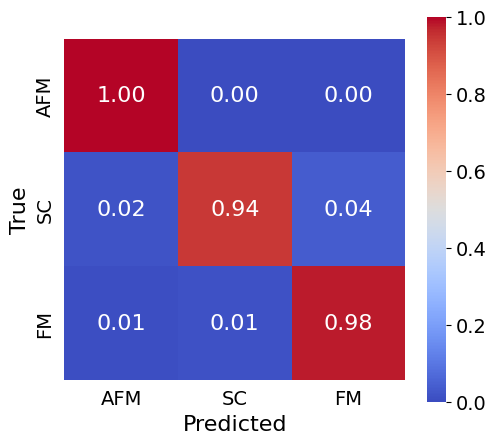

2_1_1_ld32_s2000


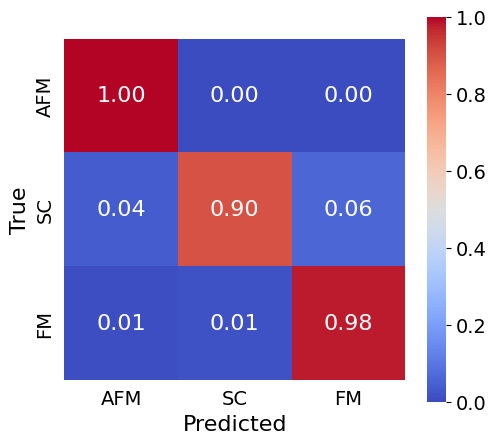

2_1_1_ld16_s24000


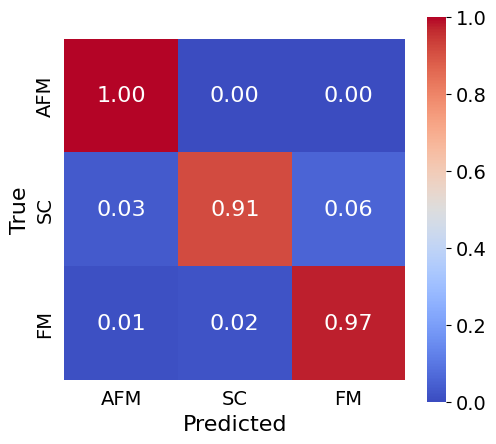

2_3_1_ld32_s24000


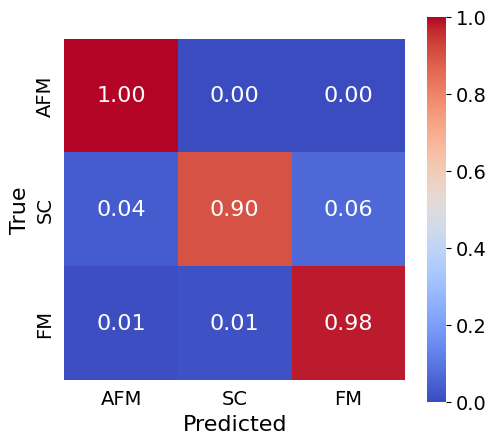

In [35]:
labels = [label.upper() for label in list(AutoEncoderVertexDataset.phase_borders.keys())]
for i, row in classification_df.iterrows():
    vertvis.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

## compare vertex reconstructions

In [2]:
base_path = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/')
vertex_path_dict = {float(fp.stem[2:6]): fp for fp in data_dir.glob('*.h5')}

In [8]:
# set the run and tp-parameter for which you want to comparte original and reconstruction
runs_to_plot = ['2_1_1_ld8', '2_1_1_ld32']
tp_to_plot = [0.22, 0.33]

vertices = [AutoEncoderVertex24x6Dataset.load_from_file(vertex_path_dict[tp]) for tp in tp_to_plot]
predictions = {run_id: [np.load(base_path / run_id / 'predictions' / (vertex_path_dict[tp].stem + '.npy')) for tp in tp_to_plot] 
               for run_id in runs_to_plot}

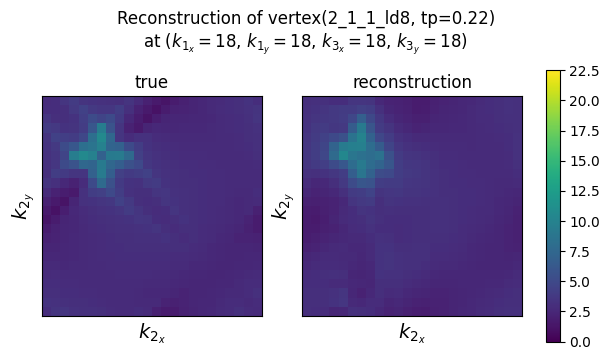

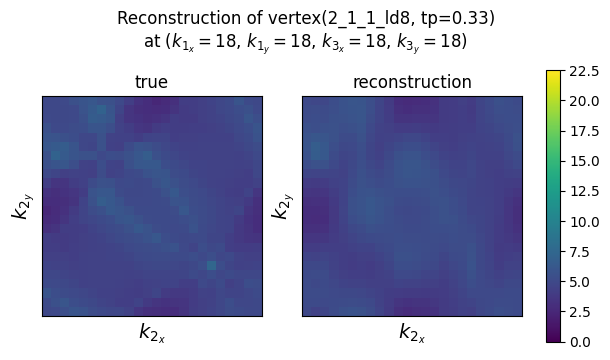

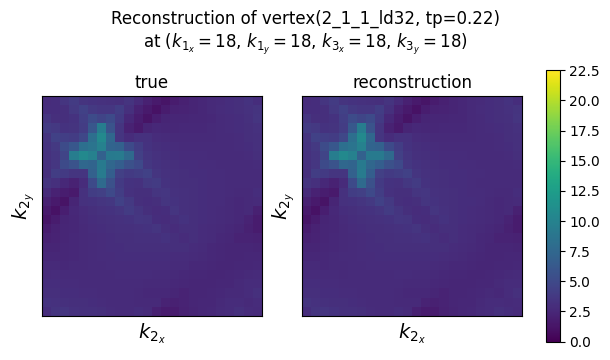

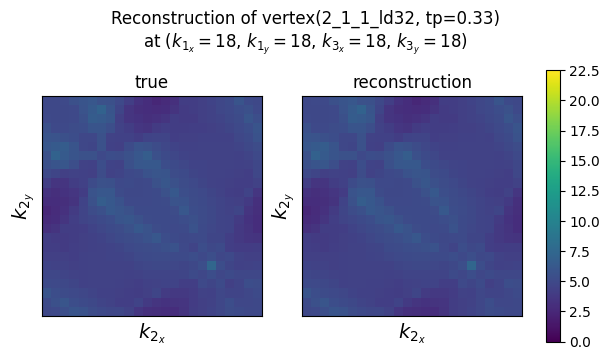

In [9]:
i = 18
axis = 3
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
other_ks = set(range(1,4)) - {(axis + 1) // 2}
params_str = ', '.join([f'$k_{{{k}_{c}}}={sl}$' for (k, c), sl 
                        in zip([(k, c) for k in other_ks for c in ['x', 'y']], slice_at)])

for run_id, preds in predictions.items():
    for tp, true, pred in zip(tp_to_plot, vertices, preds):
        fn = vertex_path_dict[tp].stem
        true_slice = vertvis.get_mat_slice(true, axis, slice_at)
        pred_slice = vertvis.get_mat_slice(pred, axis, slice_at)
        plot_data = {'true': true_slice, 'reconstruction': pred_slice}
        vertvis.plot_compare_grid(plot_data, nrows, ncols, axis, None, figsize=(6, 4), 
                                  title=f'Reconstruction of vertex({run_id}, tp={tp})\nat ({params_str})', vmin=0.0, vmax=22.5)